# 1D Steady Heat Conduction in a Rod
### CFD Assignment 1

In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import inspect
import matplotlib.pyplot as plt

from src.geometry import RectangleSpace, CellCentredGrid
from src.fields import InternalScalarField, SimpleWallBC
from src.control_volume import Diffusion

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [66]:
# 1. Create the space for the rod.
# The y and z lengths are 0.1 because Assignment 1 wants 10^{-2} as the area
rod = RectangleSpace([[0,0.5],[0,0.1],[0,0.1]])
type(rod)

src.geometry.RectangleSpace

In [67]:
# 2. Make a grid object, 'cell' means this grid is cell centered.
# Cell centered means the number 10 here means the amount of cells.
rod_grid = rod.grid('cell',[10])
type(rod_grid)


src.geometry.CellCentredGrid

In [68]:
rod_grid.faces
# Notice the shape of the first item (x axis coordinates) have shape (11,) not (10,)

[array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ]),
 array([0. , 0.1]),
 array([0. , 0.1])]

In [69]:
# 3 A field needs a boundary condition, so we create one here
heated_ends = SimpleWallBC(
    wall_values = [[100,500],[0,0],[0,0]],
    derivative_order= [[0,0],[1,1],[1,1]]
)
# 100 and 500 is the heat held constant at the ends of the x axis, indicates that these values are field values.
# Neumann: [1,1] derivative order corresponds to the [0,0] wall values, meaning the 1st derivative of the temperature at that face is zero. 
# Dirichlet: [0,0] derivative order corresponds to [100,500] wall values, meaning the temperature at that face is 100 and 500.
vars(heated_ends)

{'wall_values': array([[100., 500.],
        [  0.,   0.],
        [  0.,   0.]]),
 'derivative_order': array([[0, 0],
        [1, 1],
        [1, 1]])}

In [70]:
# 4. Create the scalar field value with the above grid and bcs
temperature_field = InternalScalarField(
    grid=rod_grid,
    bcs=heated_ends
)
vars(temperature_field)

{'grid': <src.geometry.CellCentredGrid at 0x12ccd0cf360>,
 'bcs': <src.fields.SimpleWallBC at 0x12ccea27230>,
 'values': None}

In [71]:
# 5. Create Diffusion object. This will help assemble the matrix
rod_problem = Diffusion(
    field=temperature_field,
    diffusion_coefficient=100
)
# The diffusion_coefficient is constant, 100 for all of them given by Assignment 1
vars(rod_problem)

{'field': <src.fields.InternalScalarField at 0x12cceb94050>,
 'diffusion_coefficient': 100}

In [72]:
# 6. Control Volume Method needs diffusion conducatances, this is in the module below
rod_problem.diffusion_conductances()

[array([40., 20., 20., 20., 20., 20., 20., 20., 20., 20., 40.]),
 array([10., 10.]),
 array([10., 10.])]

In [73]:
# One conductance per face (11 faces): 20 between cells (a_W, a_E), 40 at the walls (half-cell distance).
# a_P = sum of a cell's two face conductances: 40 inside, 60 at the ends (see the matrix diagonal below).
print(inspect.signature(Diffusion))
print(inspect.getsource(Diffusion.diffusion_conductances))

(field, diffusion_coefficient)
    def diffusion_conductances(self):
        target_list = []
        g = self.field.grid
        for axis in range(g.dim):
            singledim_diffusion_conductances = (self.diffusion_coefficient * g.areas[axis]) * (1/g.centre_spacing[axis])
            target_list.append(singledim_diffusion_conductances)
        return target_list



In [74]:
# 6. Calculation inside hte diffusion conductance module
# singledim_diffusion_conductances = (self.diffusion_coefficient * g.areas[axis]) * (1/g.centre_spacing[axis])
# This line is the formula for the coefficients. Every single iteration are uniform except for the end points of the centre_spacing
# The end points are calculated in the grid module
print(inspect.getsource(CellCentredGrid.centre_spacing.func))

    @cached_property
    def centre_spacing(self):
        centre_spacing_list = []
        for axis in range(self.dim):
            singledim_centres = self.centres[axis]
            singledim_faces = self.faces[axis]
            singledim_centre_spacing = (singledim_centres[1:]-singledim_centres[:-1])
            

            # For the first and last centres, we need distance to the space boundaries
            singledim_first_dist =  singledim_centres[0] - singledim_faces[0]
            singledim_last_dist = singledim_faces[-1] - singledim_centres[-1]

            singledim_centre_spacing = np.concatenate(([singledim_first_dist],singledim_centre_spacing,[singledim_last_dist]))

            centre_spacing_list.append(singledim_centre_spacing)

        return centre_spacing_list
        ### 6. CELL LENGTHS (uniform grid: one face-to-face width per axis)
        # Every cell along an axis has the same width, so the first two faces are enough



In [75]:

# 7. Assemble the matrix and rhs vector using the .assemble() method
rod_lineqs = rod_problem.assemble()
vars(rod_lineqs)

{'matrix': array([[ 60., -20.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [-20.,  40., -20.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0., -20.,  40., -20.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0., -20.,  40., -20.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0., -20.,  40., -20.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0., -20.,  40., -20.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0., -20.,  40., -20.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0., -20.,  40., -20.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0., -20.,  40., -20.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., -20.,  60.]]),
 'rhs_vector': array([ 4000.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0., 20000.]),
 'unknown_vector': None}

In [76]:
# 7. Assignment 1 asked to use a general matrix solver:
temp_simulated = np.linalg.solve(rod_lineqs.matrix, rod_lineqs.rhs_vector)
print(temp_simulated)

[120. 160. 200. 240. 280. 320. 360. 400. 440. 480.]


### Analytical solution

Steady, 1D, source-free conduction with constant $k$:

$$
\frac{d}{dx}\left(k\frac{dT}{dx}\right) = 0 \quad\Rightarrow\quad \frac{d^2T}{dx^2} = 0
$$

Integrate twice:

$$
\frac{dT}{dx} = C_1 \quad\Rightarrow\quad T(x) = C_1 x + C_2
$$

Apply the boundary conditions $T(0) = T_A$ and $T(L) = T_B$:

$$
C_2 = T_A, \qquad C_1 = \frac{T_B - T_A}{L}
$$

$$
\boxed{T(x) = T_A + \frac{T_B - T_A}{L}\,x = 100 + 800\,x}
$$

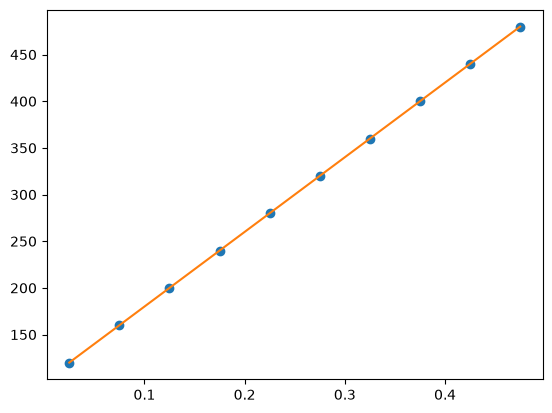

In [82]:
# The line above corresponds to
T_exact = 100 + 800 * rod_grid.centres[0]
# We will now plot:
x = rod_grid.centres[0] #--> Since each temperature lives on each grid.
plt.plot(x, temp_simulated, 'o')
plt.plot(x, T_exact)

For this particular case, the simulation is exact. Since the model is 1st degree linear and the math is also linear.